# Electricity Balance Plot

This notebook reads `ipps_solution_timeseries.csv` and plots electricity production/supply above zero, electricity use below zero, electric hot-utility demand, clean heat routing, and battery inventory `I_B` on a secondary y-axis.

If the CSV does not include detailed use columns such as `E_N`, `E_U`, `P_HU_el`, and battery charge/discharge yet, the notebook adds a clearly labelled residual bar called `Other/unreported use or surplus` so the plot still balances. Re-run `3ipps_green_urea_omlt_modified.py` after the export update to get the detailed breakdown directly in the CSV.

In [ ]:
!pip install path

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting_compat import normalize_result_columns

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

CSV_PATH = Path("ipps_solution_smallhorizon_free_grid.csv")

# Adjust these if the full-year CSV is too dense for a single figure.
PLOT_START = 390
PLOT_END = 450  # set to e.g. 168 to plot the first week of hourly data
ELECTRICITY_BALANCE_YMAX = 1100

# If detailed electricity-use columns are missing, add a balance residual bar.
ADD_BALANCE_RESIDUAL = True

raw = normalize_result_columns(pd.read_csv(CSV_PATH))
plot_df = raw.iloc[PLOT_START:PLOT_END].copy()
plot_df.head()

ModuleNotFoundError: No module named 'numpy'

In [ ]:
def available_components(df, components):
    return [(col, label, color) for col, label, color in components if col in df.columns]


def numeric_series(df, col):
    return pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)


time = pd.to_numeric(plot_df["t"], errors="coerce") if "t" in plot_df.columns else pd.Series(plot_df.index, index=plot_df.index)
x = time.to_numpy()

supply_components = [
    ("P_wind", "Wind electricity", "#4daf4a"),
    ("P_grid", "Grid import", "#377eb8"),
    ("dis_B", "Battery discharge", "#984ea3"),
]

use_components = [
    ("P_el", "Electrolyzer", "#ff7f00"),
    ("E_N", "Nitrate unit", "#e41a1c"),
    ("E_U", "Urea unit", "#a65628"),
    ("P_HU_el", "Electric hot utility", "#ffd92f"),
    ("e_Hstor", "H2 storage electricity", "#f781bf"),
    ("e_Cstor", "CO2 storage electricity", "#999999"),
    ("e_Wstor", "Feedwater storage electricity", "#66c2a5"),
    ("ch_B", "Battery charge", "#6a3d9a"),
]

routing_components = [
    ("P_wind_to_el", "Wind -> H2 production/compression", "#1b9e77"),
    ("P_wind_to_heat", "Wind -> electric hot utility", "#e6ab02"),
    ("P_wind_to_batt", "Wind -> battery charge", "#7570b3"),
    ("P_batt_to_el", "Battery -> H2 production/compression", "#d95f02"),
    ("P_batt_to_heat", "Battery -> electric hot utility", "#a6761d"),
]

h2_supply_components = [
    ("M_H2_prod", "Electrolyzer H2 production", "#1b9e77"),
    ("dis_H", "H2 storage discharge", "#7570b3"),
]

h2_use_components = [
    ("F_H2", "H2 feed to nitrate unit", "#d95f02"),
    ("ch_H", "H2 storage charge", "#e7298a"),
]

nh3_supply_components = [
    ("M_NH3_out", "Stripper NH3 output", "#1b9e77"),
    ("dis_NH3", "NH3 storage discharge", "#7570b3"),
]

nh3_use_components = [
    ("F_NH3", "NH3 feed to urea", "#d95f02"),
    ("ch_NH3", "NH3 storage charge", "#e7298a"),
]

available_supply = available_components(plot_df, supply_components)
available_use = available_components(plot_df, use_components)
available_routing = available_components(plot_df, routing_components)
available_h2_supply = available_components(plot_df, h2_supply_components)
available_h2_use = available_components(plot_df, h2_use_components)
available_nh3_supply = available_components(plot_df, nh3_supply_components)
available_nh3_use = available_components(plot_df, nh3_use_components)

BATTERY_TOL = 1e-6
NH3_TOL = 1e-6
ETA_B_CH = 0.95
ETA_B_DIS = 0.95
ETA_N_CH = 0.995
ETA_N_DIS = 0.995

battery_flow_cols = ["ch_B", "dis_B", "P_wind_to_batt", "P_batt_to_el", "P_batt_to_heat"]
battery_flow_max = max(
    (np.nanmax(np.abs(numeric_series(plot_df, col))) for col in battery_flow_cols if col in plot_df.columns),
    default=0.0,
)
battery_inventory = numeric_series(plot_df, "I_B") if "I_B" in plot_df.columns and len(plot_df) > 0 else np.array([])
battery_inventory_max = np.nanmax(np.abs(battery_inventory)) if battery_inventory.size else 0.0
battery_inventory_span = (np.nanmax(battery_inventory) - np.nanmin(battery_inventory)) if battery_inventory.size else 0.0
battery_active = battery_flow_max > BATTERY_TOL or battery_inventory_span > BATTERY_TOL

nh3_storage_flow_cols = ["ch_NH3", "dis_NH3"]
nh3_storage_flow_max = max(
    (np.nanmax(np.abs(numeric_series(plot_df, col))) for col in nh3_storage_flow_cols if col in plot_df.columns),
    default=0.0,
)
nh3_inventory = numeric_series(plot_df, "I_NH3") if "I_NH3" in plot_df.columns and len(plot_df) > 0 else np.array([])
nh3_inventory_max = np.nanmax(np.abs(nh3_inventory)) if nh3_inventory.size else 0.0
nh3_inventory_span = (np.nanmax(nh3_inventory) - np.nanmin(nh3_inventory)) if nh3_inventory.size else 0.0
nh3_storage_active = nh3_storage_flow_max > NH3_TOL or nh3_inventory_span > NH3_TOL

missing_use = [col for col, _, _ in use_components if col not in plot_df.columns]
if missing_use:
    print("Missing detailed electricity-use columns:", ", ".join(missing_use))

supply_total = sum((numeric_series(plot_df, col) for col, _, _ in available_supply), start=np.zeros(len(plot_df)))
known_use_total = sum((numeric_series(plot_df, col) for col, _, _ in available_use), start=np.zeros(len(plot_df)))

if ADD_BALANCE_RESIDUAL and missing_use and len(plot_df) > 0:
    residual = np.maximum(supply_total - known_use_total, 0.0)
    if np.nanmax(residual) > 1e-8:
        plot_df["other_unreported_use_or_surplus"] = residual
        available_use.append(("other_unreported_use_or_surplus", "Other/unreported use or surplus", "#bdbdbd"))

print(f"Plotting {len(plot_df)} rows from {CSV_PATH}")
print("Supply components:", ", ".join(label for _, label, _ in available_supply) or "none")
print("Use components:", ", ".join(label for _, label, _ in available_use) or "none")
print("Routing components:", ", ".join(label for _, label, _ in available_routing) or "none")
print("Hydrogen components:", ", ".join(label for _, label, _ in (available_h2_supply + available_h2_use)) or "none")
print("Ammonia components:", ", ".join(label for _, label, _ in (available_nh3_supply + available_nh3_use)) or "none")
if "P_HU_el" in plot_df.columns:
    print(f"Electric hot utility max load: {np.nanmax(numeric_series(plot_df, 'P_HU_el')):.6g}")
if "B_cap" in plot_df.columns:
    print(f"Battery capacity (B_cap): {pd.to_numeric(plot_df['B_cap'], errors='coerce').iloc[0]:.6g}")
if "NH3_cap" in plot_df.columns:
    print(f"NH3 storage capacity (NH3_cap): {pd.to_numeric(plot_df['NH3_cap'], errors='coerce').iloc[0]:.6g}")
print(f"Battery flow max magnitude: {battery_flow_max:.6g}")
print(f"Battery inventory max magnitude: {battery_inventory_max:.6g}")
print(f"Battery inventory span: {battery_inventory_span:.6g}")
print(f"NH3 storage flow max magnitude: {nh3_storage_flow_max:.6g}")
print(f"NH3 inventory max magnitude: {nh3_inventory_max:.6g}")
print(f"NH3 inventory span: {nh3_inventory_span:.6g}")
if battery_flow_max <= BATTERY_TOL and battery_inventory_span <= BATTERY_TOL:
    print("Battery is inactive within tolerance in this solution, so no meaningful battery bars or inventory line should appear.")
if nh3_storage_flow_max <= NH3_TOL and nh3_inventory_span <= NH3_TOL:
    print("NH3 storage is inactive within tolerance in this solution, so only direct NH3 process flow may appear.")

if all(col in plot_df.columns for col in ["I_B", "ch_B", "dis_B"]) and len(plot_df) > 0:
    inv = numeric_series(plot_df, "I_B")
    ch = numeric_series(plot_df, "ch_B")
    dis = numeric_series(plot_df, "dis_B")
    prev_inv = np.concatenate(([inv[-1]], inv[:-1]))
    battery_balance_residual = inv - prev_inv - ETA_B_CH * ch + dis / ETA_B_DIS
    print(f"Battery balance residual max abs: {np.nanmax(np.abs(battery_balance_residual)):.6g}")

if all(col in plot_df.columns for col in ["P_HU_el", "P_wind_to_heat", "P_batt_to_heat"]) and len(plot_df) > 0:
    heat_allocation_residual = numeric_series(plot_df, "P_HU_el") - numeric_series(plot_df, "P_wind_to_heat") - numeric_series(plot_df, "P_batt_to_heat")
    print(f"Electric hot utility allocation residual max abs: {np.nanmax(np.abs(heat_allocation_residual)):.6g}")

if all(col in plot_df.columns for col in ["P_HU_el", "Q_HU"]) and len(plot_df) > 0:
    heat_conversion_residual = numeric_series(plot_df, "P_HU_el") - numeric_series(plot_df, "Q_HU")
    print(f"Electric hot utility conversion residual max abs: {np.nanmax(np.abs(heat_conversion_residual)):.6g}")

if all(col in plot_df.columns for col in ["I_NH3", "ch_NH3", "dis_NH3"]) and len(plot_df) > 0:
    inv = numeric_series(plot_df, "I_NH3")
    ch = numeric_series(plot_df, "ch_NH3")
    dis = numeric_series(plot_df, "dis_NH3")
    prev_inv = np.concatenate(([inv[-1]], inv[:-1]))
    nh3_balance_residual = inv - prev_inv - ETA_N_CH * ch + dis / ETA_N_DIS
    print(f"NH3 storage balance residual max abs: {np.nanmax(np.abs(nh3_balance_residual)):.6g}")


Missing detailed electricity-use columns: e_Wstor
Plotting 60 rows from ipps_solution_smallhorizon_free_grid.csv
Supply components: Wind electricity, Grid import, Battery discharge
Use components: Electrolyzer, Nitrate unit, Urea unit, Electric hot utility, H2 storage electricity, CO2 storage electricity, Battery charge
Routing components: Wind -> battery charge
Hydrogen components: Electrolyzer H2 production, H2 storage discharge, H2 feed to nitrate unit, H2 storage charge
Ammonia components: Stripper NH3 output, NH3 storage discharge, NH3 feed to urea, NH3 storage charge
Electric hot utility max load: 0
Battery capacity (B_cap): 551.232
NH3 storage capacity (NH3_cap): 0
Battery flow max magnitude: 5.4945
Battery inventory max magnitude: 522.152
Battery inventory span: 128.006
NH3 storage flow max magnitude: 0
NH3 inventory max magnitude: 0
NH3 inventory span: 0
NH3 storage is inactive within tolerance in this solution, so only direct NH3 process flow may appear.
Battery balance resid

In [ ]:
# Static plotting moved into the interactive widget below.
# Run the widget cell to explore electricity, battery, hydrogen, and NH3 storage views
# without keeping stale figures from older notebook outputs.


In [ ]:
# Static plotting moved into the interactive widget below.
# Run the widget cell to explore electricity, battery, hydrogen, and NH3 storage views
# without keeping stale figures from older notebook outputs.


In [ ]:
# Optional: save the most recent figure.
# OUTPUT_FIG = Path("electricity_balance_plot.png")
# fig.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight")
# print(f"Saved {OUTPUT_FIG.resolve()}")

In [4]:
!pip install ipywidgets
!pip install ipympl
!pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Sunoy\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Sunoy\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Sunoy\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [ ]:
# Interactive plotting dashboard for electricity, battery, hydrogen, and NH3 storage.
# Controls are rendered once; only the plot pane is cleared and redrawn on change.

from IPython.display import display
import ipywidgets as widgets
from pathlib import Path
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

get_ipython().run_line_magic("matplotlib", "inline")
print("Interactive dashboard will refresh the plot pane on every change.")

interactive_df = plot_df.reset_index(drop=True).copy()
interactive_x = (
    pd.to_numeric(interactive_df["t"], errors="coerce")
    if "t" in interactive_df.columns
    else pd.Series(interactive_df.index, index=interactive_df.index)
).to_numpy()

saved_views_dir = Path("saved_electricity_balance_views")
saved_views_dir.mkdir(exist_ok=True)

current_view = {
    "png_bytes": b"",
    "start": 0,
    "end": max(len(interactive_df) - 1, 0),
    "mode": "Electricity balance",
}

plot_mode = widgets.Dropdown(
    options=[
        "Electricity balance",
        "Battery and routing",
        "Hydrogen storage",
        "Ammonia storage",
        "Curtailment",
    ],
    value="Electricity balance",
    description="Plot",
)

window_slider = widgets.IntRangeSlider(
    value=(0, max(len(interactive_df) - 1, 0)),
    min=0,
    max=max(len(interactive_df) - 1, 0),
    step=1,
    description="Rows",
    continuous_update=False,
    layout=widgets.Layout(width="95%"),
)

show_inventory = widgets.Checkbox(
    value=True,
    description="Show inventory",
)

filename_box = widgets.Text(
    value="interactive_storage_plot.png",
    description="Save as",
)

save_button = widgets.Button(
    description="Save current view",
    button_style="success",
    icon="save",
)

status_html = widgets.HTML()
plot_image = widgets.Image(format="png", layout=widgets.Layout(border="1px solid #ddd", padding="6px"))
plot_message = widgets.HTML()


def close_current_figure():
    return None


def figure_to_png_bytes(fig_local):
    buffer = io.BytesIO()
    fig_local.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    buffer.seek(0)
    return buffer.getvalue()


def add_inventory_axes(fig_local, ax_local, window, window_x, inventory_specs):
    handles = []
    labels = []
    active_count = 0

    for spec in inventory_specs:
        if not spec.get("enabled", True):
            continue
        col = spec["col"]
        if col not in window.columns:
            continue

        ax_inv = ax_local.twinx()
        if active_count >= 1:
            ax_inv.spines["right"].set_position(("axes", 1.12 + 0.12 * (active_count - 1)))
            ax_inv.set_frame_on(True)
            ax_inv.patch.set_visible(False)

        marker = "o" if len(window) <= 50 else None
        ax_inv.plot(
            window_x,
            numeric_series(window, col),
            color=spec["color"],
            marker=marker,
            linewidth=2,
            label=spec["label"],
        )
        ax_inv.set_ylabel(spec["ylabel"], color=spec["color"])
        ax_inv.tick_params(axis="y", colors=spec["color"])
        ax_inv.spines["right"].set_edgecolor(spec["color"])

        h, l = ax_inv.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        active_count += 1

    return handles, labels, active_count


def finalize_figure(fig_local, ax_local, extra_handles, extra_labels, inventory_axis_count):
    handles1, labels1 = ax_local.get_legend_handles_labels()
    all_handles = handles1 + extra_handles
    all_labels = labels1 + extra_labels
    if all_handles:
        legend_anchor_x = 1.02 + 0.10 * max(inventory_axis_count - 1, 0)
        ax_local.legend(all_handles, all_labels, loc="upper left", bbox_to_anchor=(legend_anchor_x, 1), borderaxespad=0)

    right_rect = max(0.66, 0.86 - 0.10 * inventory_axis_count)
    fig_local.tight_layout(rect=[0, 0, right_rect, 1])
    return fig_local


def draw_stacked_balance(window, window_x, supply_components_local, use_components_local, ylabel, title, inventory_specs=None, primary_ymax=None):
    fig_width_local = max(10, min(24, len(window) * 0.45))
    bar_width_local = 0.8 if len(window) < 100 else 1.0
    fig_local, ax_local = plt.subplots(figsize=(fig_width_local, 6))

    available_supply_local = available_components(window, supply_components_local)
    available_use_local = available_components(window, use_components_local)

    if available_supply_local or available_use_local:
        positive_bottom = np.zeros(len(window))
        for col, label, color in available_supply_local:
            values = numeric_series(window, col)
            ax_local.bar(window_x, values, bottom=positive_bottom, width=bar_width_local, label=label, color=color)
            positive_bottom += values

        negative_bottom = np.zeros(len(window))
        for col, label, color in available_use_local:
            values = -numeric_series(window, col)
            ax_local.bar(window_x, values, bottom=negative_bottom, width=bar_width_local, label=label, color=color)
            negative_bottom += values
    else:
        ax_local.text(0.5, 0.5, "No matching columns found in the CSV for this view.", ha="center", va="center", transform=ax_local.transAxes)

    ax_local.axhline(0.0, color="black", linewidth=0.9)
    ax_local.set_xlabel("Time period")
    ax_local.set_ylabel(ylabel)
    ax_local.set_title(title)
    if primary_ymax is not None:
        ax_local.set_ylim(-primary_ymax, primary_ymax)

    extra_handles, extra_labels, inventory_axis_count = add_inventory_axes(
        fig_local,
        ax_local,
        window,
        window_x,
        inventory_specs or [],
    )
    return finalize_figure(fig_local, ax_local, extra_handles, extra_labels, inventory_axis_count)


def draw_routing_balance(window, window_x, include_inventory=True):
    fig_width_local = max(10, min(24, len(window) * 0.45))
    bar_width_local = 0.8 if len(window) < 100 else 1.0
    fig_local, ax_local = plt.subplots(figsize=(fig_width_local, 6))

    routing_local = available_components(window, routing_components)
    battery_local = available_components(window, [
        ("dis_B", "Battery discharge", "#984ea3"),
        ("ch_B", "Battery charge", "#6a3d9a"),
    ])

    if routing_local or battery_local:
        positive_bottom = np.zeros(len(window))
        for col, label, color in routing_local:
            values = numeric_series(window, col)
            ax_local.bar(window_x, values, bottom=positive_bottom, width=bar_width_local, label=label, color=color)
            positive_bottom += values

        for col, label, color in battery_local:
            values = numeric_series(window, col)
            if col == "ch_B":
                values = -values
            ax_local.bar(window_x, values, width=bar_width_local, label=label, color=color, alpha=0.45)
    else:
        ax_local.text(0.5, 0.5, "No routing or battery-flow columns found in the CSV.", ha="center", va="center", transform=ax_local.transAxes)

    ax_local.axhline(0.0, color="black", linewidth=0.9)
    ax_local.set_xlabel("Time period")
    ax_local.set_ylabel("Electricity routed (kWh/h or kW-equivalent)")
    title_suffix = " (battery inactive)" if not battery_active else ""
    ax_local.set_title(f"Battery, Hydrogen, and Heat Routing: rows {window.index.min()} to {window.index.max()}" + title_suffix)

    inventory_specs = []
    if include_inventory:
        inventory_specs.append({
            "col": "I_B",
            "label": "Battery inventory (I_B)",
            "ylabel": "Battery inventory (kWh)",
            "color": "black",
            "enabled": battery_active and ("I_B" in window.columns),
        })
        inventory_specs.append({
            "col": "I_NH3",
            "label": "NH3 inventory (I_NH3)",
            "ylabel": "NH3 inventory (kg)",
            "color": "#1f78b4",
            "enabled": "I_NH3" in window.columns,
        })

    extra_handles, extra_labels, inventory_axis_count = add_inventory_axes(fig_local, ax_local, window, window_x, inventory_specs)
    return finalize_figure(fig_local, ax_local, extra_handles, extra_labels, inventory_axis_count)


def draw_curtailment(window, window_x, include_inventory=True):
    fig_width_local = max(10, min(24, len(window) * 0.45))
    bar_width_local = 0.8 if len(window) < 100 else 1.0
    fig_local, ax_local = plt.subplots(figsize=(fig_width_local, 6))

    work = window.copy()
    required_cols = ["P_wind", "P_grid", "dis_B", "P_el", "E_N", "E_U", "P_HU_el", "e_Hstor", "e_Cstor", "e_Wstor", "ch_B"]
    for col in required_cols:
        if col not in work.columns:
            work[col] = 0.0

    curtailment = (
        work["P_wind"] + work["P_grid"] + work["dis_B"]
        - work["P_el"] - work["E_N"] - work["E_U"] - work["P_HU_el"] - work["e_Hstor"] - work["e_Cstor"] - work["e_Wstor"] - work["ch_B"]
    )

    ax_local.bar(window_x, curtailment, width=bar_width_local, color="#4daf4a", label="Curtailment")
    ax_local.axhline(0.0, color="black", linewidth=0.9)
    ax_local.set_xlabel("Time period")
    ax_local.set_ylabel("Curtailment (kWh/h or kW-equivalent)")
    ax_local.set_title(f"Electricity Curtailment: rows {window.index.min()} to {window.index.max()}")

    inventory_specs = []
    if include_inventory:
        inventory_specs.append({
            "col": "I_B",
            "label": "Battery inventory (I_B)",
            "ylabel": "Battery inventory (kWh)",
            "color": "black",
            "enabled": battery_active and ("I_B" in window.columns),
        })
        inventory_specs.append({
            "col": "I_NH3",
            "label": "NH3 inventory (I_NH3)",
            "ylabel": "NH3 inventory (kg)",
            "color": "#1f78b4",
            "enabled": "I_NH3" in window.columns,
        })

    extra_handles, extra_labels, inventory_axis_count = add_inventory_axes(fig_local, ax_local, window, window_x, inventory_specs)
    return finalize_figure(fig_local, ax_local, extra_handles, extra_labels, inventory_axis_count)


def build_figure(mode, start_idx, end_idx, include_inventory=True):
    window = interactive_df.iloc[start_idx:end_idx + 1].copy()
    window_x = interactive_x[start_idx:end_idx + 1]

    if mode == "Electricity balance":
        title_suffix = " (battery inactive)" if not battery_active else ""
        inventory_specs = []
        if include_inventory:
            inventory_specs.append({
                "col": "I_B",
                "label": "Battery inventory (I_B)",
                "ylabel": "Battery inventory (kWh)",
                "color": "black",
                "enabled": battery_active and ("I_B" in window.columns),
            })
            inventory_specs.append({
                "col": "I_NH3",
                "label": "NH3 inventory (I_NH3)",
                "ylabel": "NH3 inventory (kg)",
                "color": "#1f78b4",
                "enabled": "I_NH3" in window.columns,
            })
        return draw_stacked_balance(
            window,
            window_x,
            supply_components,
            use_components,
            "Electricity flow (kWh/h or kW-equivalent)",
            f"Electricity Balance: rows {start_idx} to {end_idx}" + title_suffix,
            inventory_specs=inventory_specs,
            primary_ymax=ELECTRICITY_BALANCE_YMAX,
        )

    if mode == "Battery and routing":
        return draw_routing_balance(window, window_x, include_inventory=include_inventory)

    if mode == "Hydrogen storage":
        inventory_specs = []
        if include_inventory:
            inventory_specs.append({
                "col": "I_H",
                "label": "H2 inventory (I_H)",
                "ylabel": "H2 inventory (kg)",
                "color": "black",
                "enabled": "I_H" in window.columns,
            })
        return draw_stacked_balance(
            window,
            window_x,
            h2_supply_components,
            h2_use_components,
            "Hydrogen flow (kg/h)",
            f"Hydrogen Production and Storage: rows {start_idx} to {end_idx}",
            inventory_specs=inventory_specs,
        )

    if mode == "Ammonia storage":
        title_suffix = " (NH3 storage inactive)" if not nh3_storage_active else ""
        inventory_specs = []
        if include_inventory:
            inventory_specs.append({
                "col": "I_NH3",
                "label": "NH3 inventory (I_NH3)",
                "ylabel": "NH3 inventory (kg)",
                "color": "#1f78b4",
                "enabled": "I_NH3" in window.columns,
            })
        return draw_stacked_balance(
            window,
            window_x,
            nh3_supply_components,
            nh3_use_components,
            "Ammonia flow (kg/h)",
            f"Anhydrous NH3 Production and Storage: rows {start_idx} to {end_idx}" + title_suffix,
            inventory_specs=inventory_specs,
        )

    return draw_curtailment(window, window_x, include_inventory=include_inventory)


def update_filename(_=None):
    filename_box.value = plot_mode.value.lower().replace(" ", "_") + ".png"


def refresh_plot(_=None):
    if len(interactive_df) == 0:
        current_view["png_bytes"] = b""
        plot_image.value = b""
        plot_message.value = "<span style='color:#b22222;'>No rows available to plot.</span>"
        return

    start_idx, end_idx = window_slider.value
    if end_idx < start_idx:
        start_idx, end_idx = end_idx, start_idx

    fig_local = build_figure(plot_mode.value, start_idx, end_idx, include_inventory=show_inventory.value)
    png_bytes = figure_to_png_bytes(fig_local)
    current_view["png_bytes"] = png_bytes
    current_view["start"] = start_idx
    current_view["end"] = end_idx
    current_view["mode"] = plot_mode.value
    plot_message.value = ""
    plot_image.value = png_bytes
    plt.close(fig_local)


def save_current_view(_):
    png_bytes = current_view.get("png_bytes", b"")
    if not png_bytes:
        status_html.value = "<span style='color:#b22222;'>Nothing to save yet. Render a view first.</span>"
        refresh_plot()
        return

    target_name = filename_box.value.strip() or "interactive_storage_plot.png"
    target_path = saved_views_dir / target_name
    target_path.write_bytes(png_bytes)
    status_html.value = (
        f"<span style='color:#228b22;'>Saved {current_view['mode']} rows {current_view['start']} to "
        f"{current_view['end']} to {target_path.resolve()}</span>"
    )


plot_mode.observe(update_filename, names="value")
plot_mode.observe(refresh_plot, names="value")
window_slider.observe(refresh_plot, names="value")
show_inventory.observe(refresh_plot, names="value")
save_button.on_click(save_current_view)
update_filename()

controls = widgets.VBox([
    widgets.HTML(
        "<b>Interactive storage and power viewer</b><br>"
        "Controls render once. The plot pane is fully cleared and redrawn on each change to avoid duplication."
    ),
    widgets.HBox([plot_mode, show_inventory]),
    window_slider,
    widgets.HBox([filename_box, save_button]),
    status_html,
])

dashboard = widgets.VBox([controls, plot_message, plot_image])
display(dashboard)
refresh_plot()


Interactive dashboard will refresh the plot pane on every change.


In [ ]:
# Static plotting moved into the interactive widget below.
# Run the widget cell to explore electricity, battery, hydrogen, and NH3 storage views
# without keeping stale figures from older notebook outputs.


Using F_HA for hydrous ammonia before stripper and w_HA for NH3 wt fraction.
Total hydrous ammonia before stripper: 138,717.75 kg
Total NH3 before stripper: 550.57 kg
Flow-weighted NH3 before-stripper concentration: 0.40 wt%


,t,hydrous_ammonia_before_stripper_kgph,nh3_wt_percent_before_stripper,nh3_before_stripper_kgph,nh3_produced_per_period_kg,cumulative_nh3_produced_kg
0,390,2311.962528,0.396899,9.176151,9.176151,9.176151
1,391,2311.962528,0.396899,9.176151,9.176151,18.352302
2,392,2311.962528,0.396899,9.176151,9.176151,27.528454
3,393,2311.962528,0.396899,9.176151,9.176151,36.704605
4,394,2311.962528,0.396899,9.176151,9.176151,45.880756


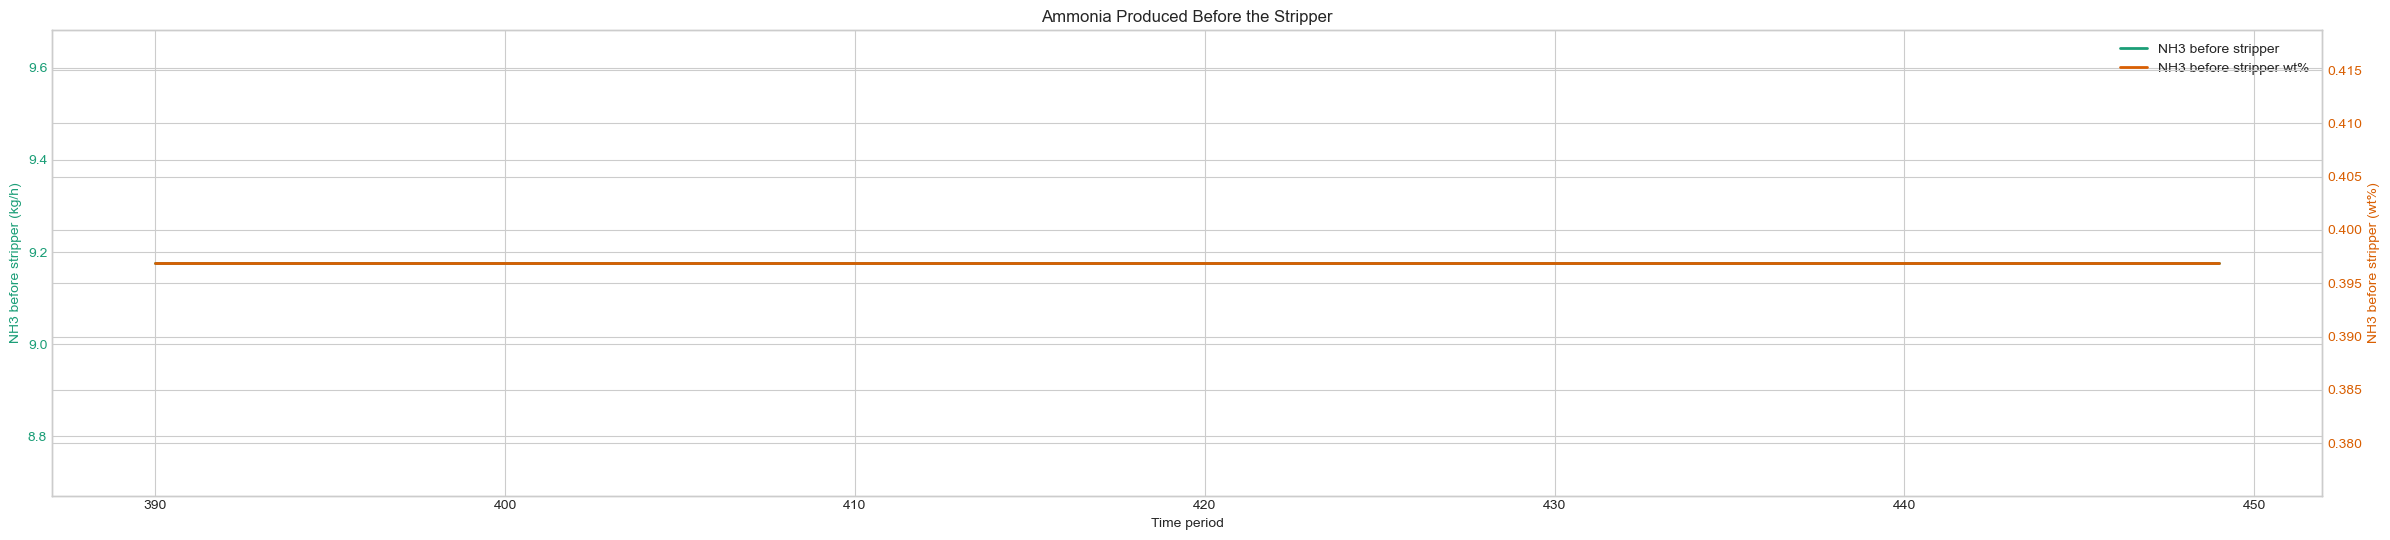

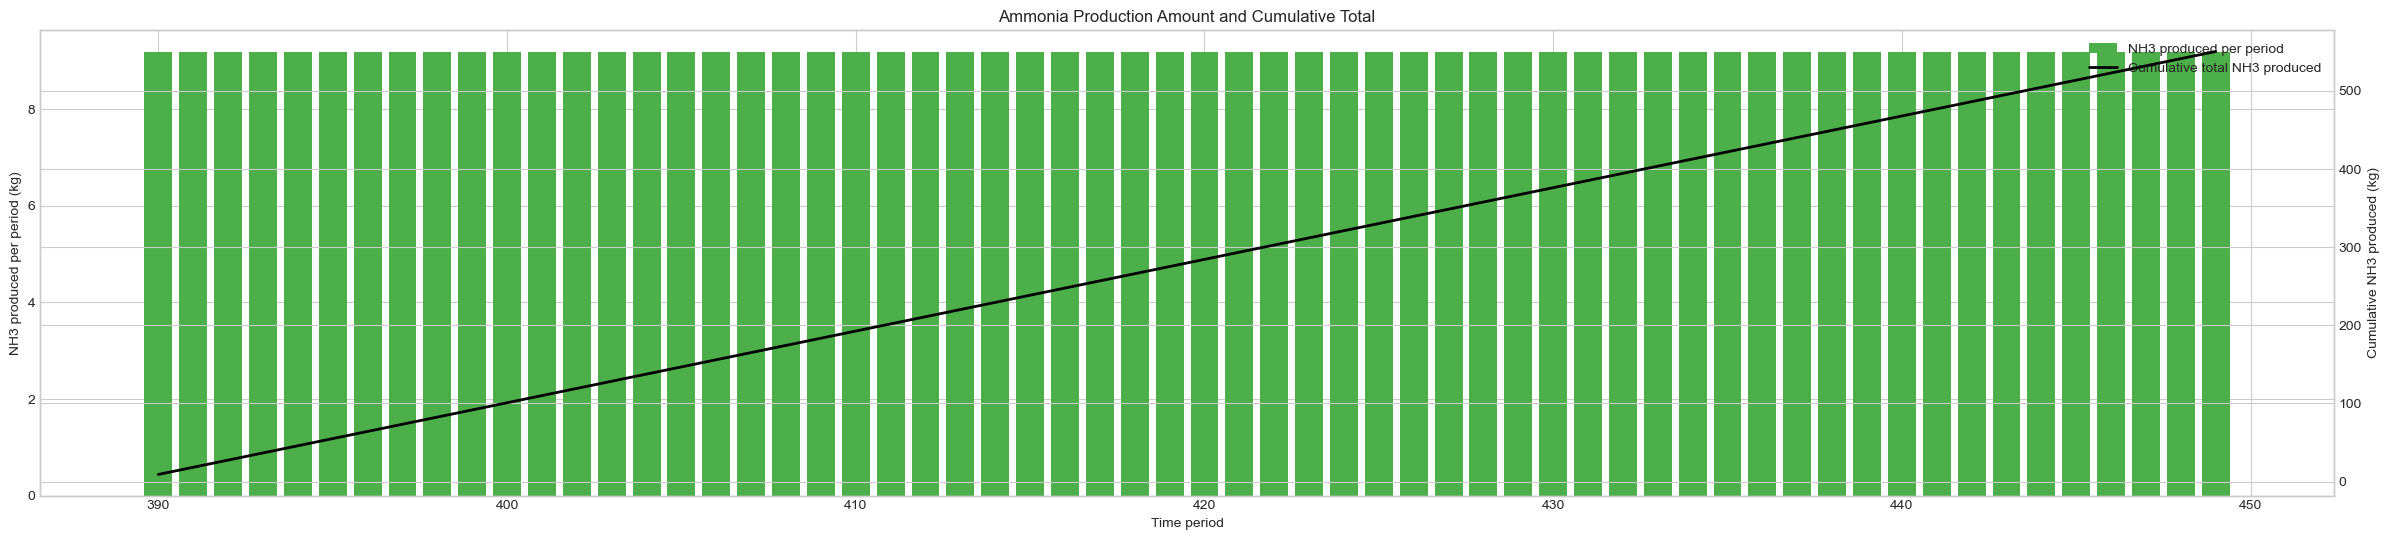

In [ ]:
if True:
    # Ammonia production before the stripper and cumulative production plot.
    # Legacy CSVs may provide F_HA / w_HA directly.
    # Current CSVs provide direct ammonia and water component flows, which are
    # converted to the same before-stripper view by plotting_compat.

    from pathlib import Path

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display

    from plotting_compat import get_before_stripper_series, normalize_result_columns

    nh3_csv_path = CSV_PATH if "CSV_PATH" in globals() else Path("ipps_solution_timeseries.csv")
    nh3_analysis_df = (
        plot_df.reset_index(drop=True).copy()
        if "plot_df" in globals()
        else normalize_result_columns(pd.read_csv(nh3_csv_path))
    )
    nh3_time = (
        pd.to_numeric(nh3_analysis_df["t"], errors="coerce")
        if "t" in nh3_analysis_df.columns
        else pd.Series(nh3_analysis_df.index, index=nh3_analysis_df.index)
    ).to_numpy()

    before_stripper = get_before_stripper_series(nh3_analysis_df)
    hydrous_nh3_col = before_stripper["hydrous_col"]
    nh3_wtfrac_col = before_stripper["wtfrac_col"]
    hydrous_ammonia_before_stripper_kgph = before_stripper["hydrous_kgph"]
    nh3_wtfrac_before_stripper = before_stripper["nh3_wtfrac"]
    nh3_wt_percent_before_stripper = 100.0 * nh3_wtfrac_before_stripper
    nh3_before_stripper_kgph = hydrous_ammonia_before_stripper_kgph * nh3_wtfrac_before_stripper

    if "dt" in nh3_analysis_df.columns:
        period_hours = pd.to_numeric(nh3_analysis_df["dt"], errors="coerce").fillna(0.0).replace(0.0, np.nan).fillna(1.0).to_numpy()
    else:
        time_steps = np.diff(nh3_time.astype(float)) if len(nh3_time) > 1 else np.array([])
        positive_steps = time_steps[np.isfinite(time_steps) & (time_steps > 0)]
        inferred_period_hours = float(np.median(positive_steps)) if positive_steps.size else 1.0
        period_hours = np.full(len(nh3_analysis_df), inferred_period_hours)

    nh3_produced_per_period_kg = nh3_before_stripper_kgph.to_numpy() * period_hours
    nh3_cumulative_kg = np.cumsum(nh3_produced_per_period_kg)

    nh3_before_stripper = pd.DataFrame({
        "t": nh3_time,
        "hydrous_ammonia_before_stripper_kgph": hydrous_ammonia_before_stripper_kgph,
        "nh3_wt_percent_before_stripper": nh3_wt_percent_before_stripper,
        "nh3_before_stripper_kgph": nh3_before_stripper_kgph,
        "nh3_produced_per_period_kg": nh3_produced_per_period_kg,
        "cumulative_nh3_produced_kg": nh3_cumulative_kg,
    })

    total_hydrous_feed_kg = float(np.sum(hydrous_ammonia_before_stripper_kgph.to_numpy() * period_hours))
    total_nh3_before_stripper_kg = float(nh3_cumulative_kg[-1]) if len(nh3_cumulative_kg) else 0.0
    weighted_wt_percent = (
        float(np.average(nh3_wt_percent_before_stripper, weights=np.maximum(hydrous_ammonia_before_stripper_kgph, 0.0)))
        if hydrous_ammonia_before_stripper_kgph.sum() > 0
        else np.nan
    )

    print(f"Using {hydrous_nh3_col} for hydrous ammonia before stripper and {nh3_wtfrac_col} for NH3 wt fraction.")
    print(f"Total hydrous ammonia before stripper: {total_hydrous_feed_kg:,.2f} kg")
    print(f"Total NH3 before stripper: {total_nh3_before_stripper_kg:,.2f} kg")
    print(f"Flow-weighted NH3 before-stripper concentration: {weighted_wt_percent:.2f} wt%")
    display(nh3_before_stripper.head())

    fig_width = max(10, min(24, len(nh3_analysis_df) * 0.45))
    marker_style = "o" if len(nh3_analysis_df) <= 50 else None

    fig, ax_amount = plt.subplots(figsize=(fig_width, 5.5))
    amount_line = ax_amount.plot(
        nh3_time,
        nh3_before_stripper_kgph,
        color="#1b9e77",
        marker=marker_style,
        linewidth=2,
        label="NH3 before stripper",
    )
    ax_amount.set_xlabel("Time period")
    ax_amount.set_ylabel("NH3 before stripper (kg/h)", color="#1b9e77")
    ax_amount.tick_params(axis="y", colors="#1b9e77")

    ax_wt = ax_amount.twinx()
    wt_line = ax_wt.plot(
        nh3_time,
        nh3_wt_percent_before_stripper,
        color="#d95f02",
        marker=marker_style,
        linewidth=2,
        label="NH3 before stripper wt%",
    )
    ax_wt.set_ylabel("NH3 before stripper (wt%)", color="#d95f02")
    ax_wt.tick_params(axis="y", colors="#d95f02")

    ax_amount.set_title("Ammonia Produced Before the Stripper")
    lines = amount_line + wt_line
    ax_amount.legend(lines, [line.get_label() for line in lines], loc="best")
    fig.tight_layout()
    plt.show()

    fig2, ax_bar = plt.subplots(figsize=(fig_width, 5.5))
    bar_width = 0.8 if len(nh3_analysis_df) < 100 else 1.0
    bars = ax_bar.bar(
        nh3_time,
        nh3_produced_per_period_kg,
        width=bar_width,
        color="#4daf4a",
        label="NH3 produced per period",
    )
    ax_bar.set_xlabel("Time period")
    ax_bar.set_ylabel("NH3 produced per period (kg)")

    ax_total = ax_bar.twinx()
    total_line = ax_total.plot(
        nh3_time,
        nh3_cumulative_kg,
        color="black",
        marker=marker_style,
        linewidth=2,
        label="Cumulative total NH3 produced",
    )
    ax_total.set_ylabel("Cumulative NH3 produced (kg)")

    ax_bar.set_title("Ammonia Production Amount and Cumulative Total")
    handles_bar, labels_bar = ax_bar.get_legend_handles_labels()
    handles_total, labels_total = ax_total.get_legend_handles_labels()
    ax_bar.legend(handles_bar + handles_total, labels_bar + labels_total, loc="best")
    fig2.tight_layout()
    plt.show()
